# Predição de Churn — EDA, Normalização e Baseline

**Tech Challenge Fase 1 — Pipeline Preditivo de Churn**

Este notebook é a evolução do `01_eda.ipynb`, reorganizado em um fluxo único e reprodutível:
análise exploratória, tratamento/normalização dos dados, engenharia de features exploratória
e construção de um **baseline** de classificação, seguindo boas práticas de Engenharia de ML
(pipelines do scikit-learn, ausência de vazamento de dados, seeds fixas, métricas adequadas
ao desbalanceamento de classes).

## Estrutura
1. Definição do problema
2. Configuração do ambiente
3. Carregamento e entendimento dos dados
4. Qualidade dos dados e normalização
5. Análise exploratória (EDA)
6. Engenharia de features (testando possibilidades)
7. Pipeline de pré-processamento + baseline
8. Treinamento, validação cruzada e avaliação
9. Testando possibilidades (comparação de variações do baseline)
10. Análise de erros
11. Conclusões e próximos passos


## 1. Definição do problema

**Contexto de negócio:** uma operadora de telecomunicações está perdendo clientes em ritmo
acelerado. A diretoria precisa de um modelo que identifique, com antecedência, clientes com
risco de cancelamento (*churn*), permitindo ações de retenção direcionadas.

**Tipo de problema de ML:** classificação binária supervisionada.
- Classe positiva (`1`): cliente cancelou o serviço (`Churn = Yes`).
- Classe negativa (`0`): cliente permaneceu (`Churn = No`).

**Hipóteses iniciais a investigar:**
- H1: clientes com menor tempo de permanência (`tenure`) têm maior probabilidade de churn.
- H2: contratos mensais (`Month-to-month`) têm taxa de churn maior que contratos anuais/bianuais.
- H3: cobranças mensais mais altas e/ou ausência de serviços de suporte (`OnlineSecurity`,
  `TechSupport`) estão associadas a maior churn.
- H4: o conjunto de dados é moderadamente desbalanceado (churn é minoria), o que exige métricas
  além da acurácia.

**Métrica técnica principal:** F1-score da classe positiva (equilibra precisão e recall, que
são igualmente relevantes no contexto de retenção: falso negativo = perder um cliente que
poderia ser retido; falso positivo = gastar recurso de retenção com quem não iria cancelar).
Como métrica auxiliar, usamos ROC-AUC, por ser independente de threshold e útil para comparar
modelos.


In [30]:
# Bibliotecas
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import seaborn as sns
from imblearn.over_sampling import SMOTE

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    confusion_matrix, classification_report, precision_recall_curve, RocCurveDisplay
)

# imbalanced-learn: pipeline compatível com sklearn que aplica reamostragem
# apenas no fit (treino), nunca no predict/transform (teste) — evita vazamento de dados
from imblearn.pipeline import Pipeline as ImbPipeline

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")


In [31]:
# Constantes e configurações — reprodutibilidade
RANDOM_STATE = 42
TEST_SIZE = 0.2
PROJECT_ROOT = Path.cwd().parent
DATA_PATH = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "WA_Fn-UseC_-Telco-Customer-Churn.csv"
)
TARGET = "Churn"

np.random.seed(RANDOM_STATE)

## 3. Carregamento e entendimento dos dados

In [32]:
dados = pd.read_csv(DATA_PATH)
print(f"Dimensões: {dados.shape[0]} linhas x {dados.shape[1]} colunas")
dados.head()


Dimensões: 7043 linhas x 21 colunas


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [33]:
dados.info()


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [34]:
# customerID é um identificador único, sem valor preditivo — confirmando
print("IDs duplicados:", dados["customerID"].duplicated().sum())
print("Linhas totalmente duplicadas:", dados.duplicated().sum())


IDs duplicados: 0
Linhas totalmente duplicadas: 0


**Observação:** não há duplicidades. `customerID` é um identificador e será removido
antes da modelagem (não carrega informação preditiva e poderia causar problemas se usado
como feature categórica de alta cardinalidade).

## 4. Qualidade dos dados e normalização

`TotalCharges` está com tipo `object`, embora seja um valor monetário. Investigamos o porquê
antes de qualquer conversão — a normalização de tipos nunca deve ser feita "às cegas".


In [35]:
# TotalCharges deveria ser numérico — investigando valores não numéricos
mask_nao_numerico = pd.to_numeric(dados["TotalCharges"], errors="coerce").isna()
print(f"Registros não numéricos em TotalCharges: {mask_nao_numerico.sum()}")
dados.loc[mask_nao_numerico, ["customerID", "tenure", "MonthlyCharges", "TotalCharges", "Churn"]]


Registros não numéricos em TotalCharges: 11


,customerID,tenure,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,0,52.55,,No
753,3115-CZMZD,0,20.25,,No
936,5709-LVOEQ,0,80.85,,No
1082,4367-NUYAO,0,25.75,,No
1340,1371-DWPAZ,0,56.05,,No
3331,7644-OMVMY,0,19.85,,No
3826,3213-VVOLG,0,25.35,,No
4380,2520-SGTTA,0,20.00,,No
5218,2923-ARZLG,0,19.70,,No
6670,4075-WKNIU,0,73.35,,No


**Hipótese confirmada:** os valores problemáticos são strings vazias (`" "`), e todos
correspondem a clientes com `tenure = 0`, ou seja, clientes muito recentes que ainda não
fecharam um ciclo de cobrança total. Faz sentido de negócio: `TotalCharges` ainda não existe
para eles.

**Decisão de tratamento:** converter para numérico com `errors="coerce"` e, como são apenas
11 registros (~0,15% da base) e nenhum apresenta churn, **remover essas linhas** em vez de
imputar um valor arbitrário — evita introduzir viés para uma fração tão pequena dos dados.
Essa decisão é revisitada nos próximos passos caso a quantidade de dados se mostre insuficiente.


In [36]:
dados["TotalCharges"] = pd.to_numeric(dados["TotalCharges"], errors="coerce")
dados = dados.dropna(subset=["TotalCharges"]).reset_index(drop=True)

# Remoção do identificador (sem valor preditivo)
dados = dados.drop(columns=["customerID"])

print(f"Dimensões após limpeza: {dados.shape[0]} linhas x {dados.shape[1]} colunas")


Dimensões após limpeza: 7032 linhas x 20 colunas


In [37]:
# Padronização de tipos categóricos: garantir strings limpas (sem espaços/inconsistências)
colunas_categoricas_totais = dados.select_dtypes(include="object").columns.tolist()
for col in colunas_categoricas_totais:
    dados[col] = dados[col].str.strip()

# Conferindo se restam valores nulos em qualquer coluna
dados.isna().sum()[dados.isna().sum() > 0]


Series([], dtype: int64)

Nenhum valor nulo remanescente. A base está estruturalmente pronta para a EDA.

## 5. Análise exploratória (EDA)

Reorganizamos a EDA em funções reutilizáveis, evitando repetição de código entre as diferentes
variáveis categóricas (como ocorria na versão anterior do notebook).


Churn
No     73.42
Yes    26.58
Name: proportion, dtype: float64


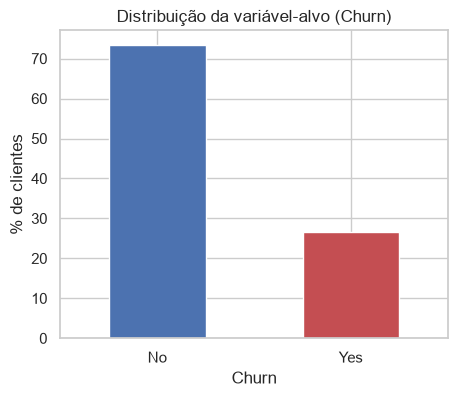

In [38]:
# Distribuição da variável-alvo
dist_churn = dados[TARGET].value_counts(normalize=True).mul(100).round(2)
print(dist_churn)

dist_churn.plot(kind="bar", color=["#4C72B0", "#C44E52"], figsize=(5, 4))
plt.title("Distribuição da variável-alvo (Churn)")
plt.ylabel("% de clientes")
plt.xticks(rotation=0)
plt.show()


**H4 confirmada:** desbalanceamento moderado — aproximadamente 73% "No" vs 27% "Yes".
Reforça a decisão de não usar acurácia como métrica principal.

In [39]:
# Variáveis numéricas: distribuição geral
colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
dados[colunas_numericas].describe().round(2)


,tenure,MonthlyCharges,TotalCharges
count,7032.00,7032.00,7032.00
mean,32.42,64.80,2283.30
std,24.55,30.09,2266.77
min,1.00,18.25,18.80
25%,9.00,35.59,401.45
50%,29.00,70.35,1397.48
75%,55.00,89.86,3794.74
max,72.00,118.75,8684.80


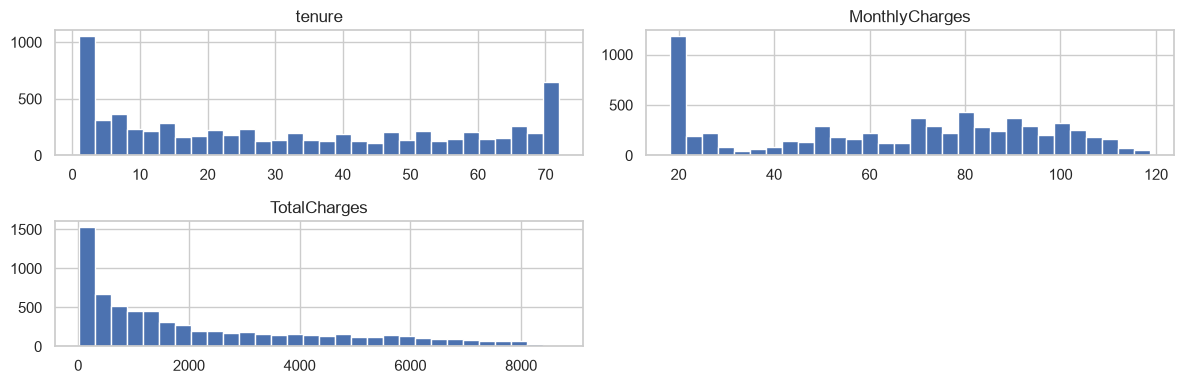

In [40]:
dados[colunas_numericas].hist(bins=30, figsize=(12, 4))
plt.tight_layout()
plt.show()


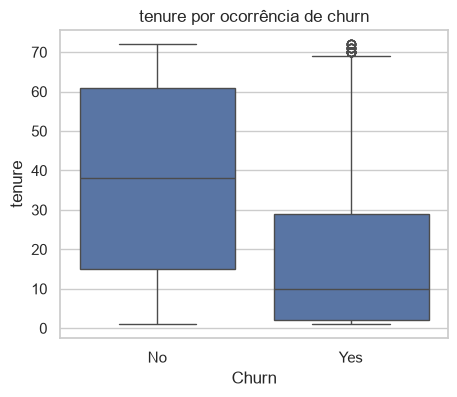

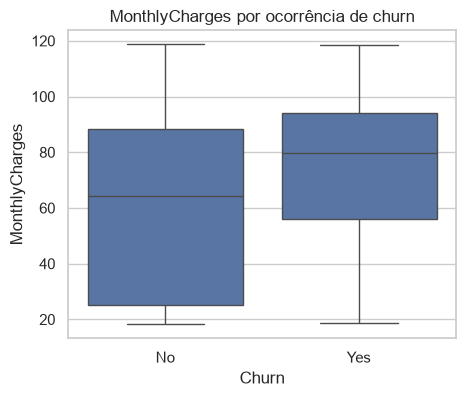

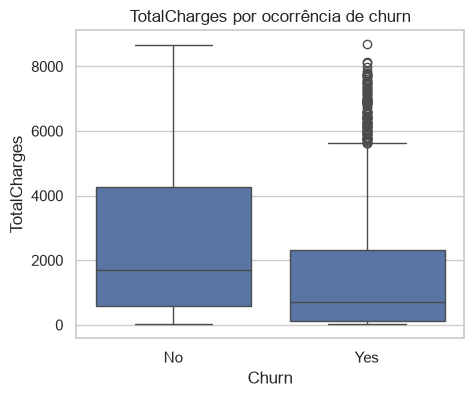

,tenure,MonthlyCharges,TotalCharges
Churn,,,
No,38.0,64.45,1683.60
Yes,10.0,79.65,703.55


In [41]:
def plot_numerica_vs_churn(df, coluna):
    """Boxplot de uma variável numérica segmentado pela variável-alvo."""
    plt.figure(figsize=(5, 4))
    sns.boxplot(data=df, x=TARGET, y=coluna)
    plt.title(f"{coluna} por ocorrência de churn")
    plt.show()

for coluna in colunas_numericas:
    plot_numerica_vs_churn(dados, coluna)

dados.groupby(TARGET)[colunas_numericas].median().round(2)


**H1 confirmada:** mediana de `tenure` é bem menor entre clientes com churn (~10 meses)
do que entre os que permaneceram (~38 meses). `MonthlyCharges` também tende a ser maior entre
quem cancela, consistente com H3.

In [42]:
def taxa_churn_por_categoria(df, coluna):
    """Retorna a taxa de churn (%) para cada categoria de uma coluna."""
    return (
        pd.crosstab(df[coluna], df[TARGET], normalize="index")
        .mul(100).round(2)["Yes"]
        .sort_values(ascending=False)
    )

def plot_taxa_churn(serie, titulo):
    plt.figure(figsize=(7, 4))
    serie.plot(kind="bar")
    plt.title(titulo)
    plt.ylabel("Taxa de churn (%)")
    plt.xticks(rotation=30, ha="right")
    plt.tight_layout()
    plt.show()


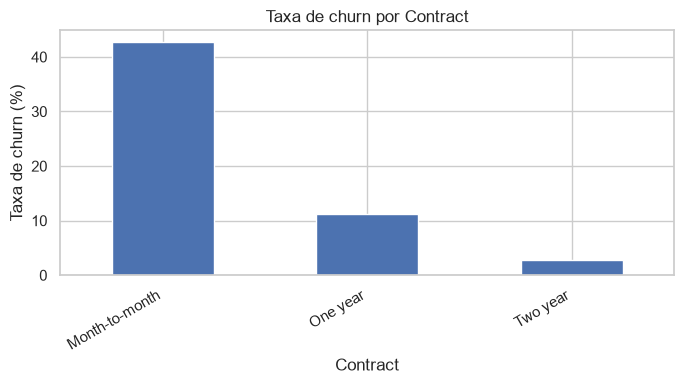

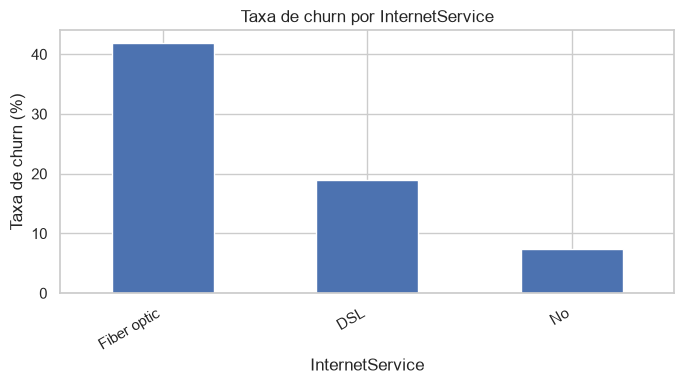

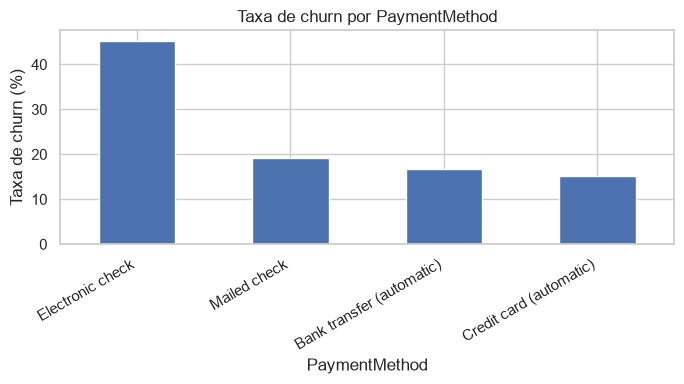

In [43]:
# Variáveis categóricas com maior relevância de negócio, avaliadas de forma sistemática
colunas_categoricas = dados.select_dtypes(include="object").columns.tolist()
colunas_categoricas.remove(TARGET)

resumo_taxas = {col: taxa_churn_por_categoria(dados, col) for col in colunas_categoricas}

# Destaque: Contract, InternetService e PaymentMethod (maiores variações observadas)
for col in ["Contract", "InternetService", "PaymentMethod"]:
    plot_taxa_churn(resumo_taxas[col], f"Taxa de churn por {col}")


**H2 confirmada:** `Contract = Month-to-month` concentra a maior taxa de churn (~43%),
contra ~11% (um ano) e ~3% (dois anos). `InternetService = Fiber optic` e
`PaymentMethod = Electronic check` também se destacam com taxas elevadas.

In [44]:
# Serviços adicionais: comparação sistemática "com" vs "sem" serviço
servicos = ["OnlineSecurity", "OnlineBackup", "DeviceProtection", "TechSupport",
            "StreamingTV", "StreamingMovies"]

comparativo_servicos = pd.DataFrame({
    servico: taxa_churn_por_categoria(dados, servico) for servico in servicos
}).T[["No", "Yes"]] if False else None

tabela_servicos = pd.DataFrame({
    servico: pd.crosstab(dados[servico], dados[TARGET], normalize="index").mul(100)["Yes"]
    for servico in servicos
}).T

tabela_servicos.columns = [f"{c} (%)" for c in tabela_servicos.columns]
tabela_servicos.round(2)


,No (%),No internet service (%),Yes (%)
OnlineSecurity,41.78,7.43,14.64
OnlineBackup,39.94,7.43,21.57
DeviceProtection,39.14,7.43,22.54
TechSupport,41.65,7.43,15.20
StreamingTV,33.54,7.43,30.11
StreamingMovies,33.73,7.43,29.95


**H3 confirmada:** ausência de `OnlineSecurity` e `TechSupport` está associada às maiores
taxas de churn (~42-48%), contra ~15% entre quem possui o serviço — o maior contraste entre
todas as variáveis categóricas analisadas.

### Síntese da EDA
- Base com desbalanceamento moderado (27% churn), sem duplicidades após limpeza.
- `tenure`, `Contract`, `InternetService`, `PaymentMethod`, `OnlineSecurity` e `TechSupport`
  são as variáveis com maior poder discriminativo aparente e serão priorizadas na leitura dos
  coeficientes do modelo baseline.
- Não há evidência de necessidade de tratamento de outliers agressivo: as variáveis numéricas
  têm ranges compatíveis com o domínio (tenure 0–72 meses, charges positivas).


## 6. Engenharia de features — testando novas possibilidades

Antes de partir direto para o baseline com as colunas originais, testamos se features
derivadas agregam sinal preditivo. Isso evita "pré-processamento desnecessário": só
mantemos o que a avaliação (seção 9) justificar.

Features candidatas:
- `num_services`: quantidade de serviços adicionais contratados (0 a 6) — hipótese de que
  clientes mais "engajados" no ecossistema de serviços cancelam menos.
- `tenure_group`: faixas de tempo de permanência — testa se a relação com churn é melhor
  capturada de forma categórica (não-linear) do que numérica contínua.


In [45]:
def engenharia_features(df):
    """Gera features derivadas. Retorna uma cópia do dataframe de entrada."""
    df = df.copy()

    servicos_adicionais = ["OnlineSecurity", "OnlineBackup", "DeviceProtection",
                            "TechSupport", "StreamingTV", "StreamingMovies"]
    df["num_services"] = (df[servicos_adicionais] == "Yes").sum(axis=1)

    df["tenure_group"] = pd.cut(
        df["tenure"],
        bins=[-1, 12, 24, 48, 72],
        labels=["0-12m", "12-24m", "24-48m", "48-72m"]
    ).astype(str)

    return df

dados_fe = engenharia_features(dados)
dados_fe[["num_services", "tenure_group"]].describe(include="all")


,num_services,tenure_group
count,7032.000000,7032
unique,NaN,4
top,NaN,48-72m
freq,NaN,2239
mean,2.038111,NaN
std,1.847161,NaN
min,0.000000,NaN
25%,0.000000,NaN
50%,2.000000,NaN
75%,3.000000,NaN


## 7. Pipeline de pré-processamento e baseline

Usamos `ColumnTransformer` + `Pipeline` do scikit-learn para garantir que **todo** o
pré-processamento (padronização de numéricas e one-hot de categóricas) seja ajustado apenas
no conjunto de treino, evitando vazamento de dados (*data leakage*) para o teste.

O split treino/teste é feito **antes** de qualquer ajuste de transformação, e é estratificado
pela variável-alvo para preservar a proporção de churn em ambos os conjuntos.

### Balanceamento com SMOTE

A EDA (seção 5) confirmou desbalanceamento moderado (~27% churn). Para que o modelo não
favoreça a classe majoritária, aplicamos **SMOTE** (Synthetic Minority Over-sampling
Technique), que gera exemplos sintéticos da classe minoritária por interpolação entre vizinhos
mais próximos no espaço de features já pré-processado (numéricas padronizadas + categóricas
codificadas).

**Ponto crítico de vazamento de dados:** SMOTE só pode ser aplicado **dentro** do pipeline de
treino, nunca no conjunto de teste (nem antes do split). Por isso usamos o `Pipeline` do
**imbalanced-learn** (`imblearn.pipeline.Pipeline`) em vez do `Pipeline` padrão do
scikit-learn — ele reamostra apenas durante o `fit`, e o `predict`/`predict_proba` no teste
(ou em cada fold de validação) usa os dados reais, sem qualquer amostra sintética. Isso é
essencial: sintetizar antes do split, ou reamostrar o conjunto de teste, inflaria as métricas
de forma artificial.


In [46]:
y = (dados[TARGET] == "Yes").astype(int)
X = dados.drop(columns=[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE
)

print(f"Treino: {X_train.shape[0]} amostras | Teste: {X_test.shape[0]} amostras")
print("Proporção de churn — treino:", y_train.mean().round(3), "| teste:", y_test.mean().round(3))


Treino: 5625 amostras | Teste: 1407 amostras
Proporção de churn — treino: 0.266 | teste: 0.266


In [47]:
colunas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]
colunas_categoricas = [c for c in X.columns if c not in colunas_numericas]

preprocessador = ColumnTransformer([
    ("num", StandardScaler(), colunas_numericas),
    ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_categoricas),
])

baseline = ImbPipeline([
    ("preprocessador", preprocessador),
    ("smote", SMOTE(random_state=RANDOM_STATE)),
    ("classificador", LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)),
])

baseline


,steps,"[('preprocessador', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for forma

In [59]:
# Conferindo o que o SMOTE faz nos dados de treino (isoladamente, só para inspeção)
X_train_transformado = preprocessador.fit_transform(X_train, y_train)
X_res, y_res = SMOTE(random_state=RANDOM_STATE).fit_resample(X_train_transformado, y_train)

print("Distribuição original (treino):", np.bincount(y_train))
print("Distribuição após SMOTE (treino):", np.bincount(y_res))
print("\nO conjunto de teste NÃO é alterado — mantém a proporção real:", np.bincount(y_test))


Distribuição original (treino): [4130 1495]
Distribuição após SMOTE (treino): [4130 4130]

O conjunto de teste NÃO é alterado — mantém a proporção real: [1033  374]


## 8. Treinamento, validação cruzada e avaliação

Antes de avaliar no teste (usado uma única vez), validamos a robustez do baseline com
validação cruzada estratificada (5 folds) no conjunto de treino. Como o `SMOTE` está dentro do
`Pipeline` do imbalanced-learn, cada fold de validação da validação cruzada permanece com a
distribuição original — a reamostragem ocorre somente na parte de treino de cada fold.


In [60]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

resultados_cv = cross_validate(
    baseline, X_train, y_train, cv=cv,
    scoring=["f1", "roc_auc", "precision", "recall"]
)

pd.DataFrame(resultados_cv)[["test_f1", "test_roc_auc", "test_precision", "test_recall"]].mean().round(3)


test_f1           0.630
test_roc_auc      0.845
test_precision    0.523
test_recall       0.792
dtype: float64

In [61]:
baseline.fit(X_train, y_train)
y_pred = baseline.predict(X_test)
y_proba = baseline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred, target_names=["No Churn", "Churn"]))
print("ROC-AUC:", round(roc_auc_score(y_test, y_proba), 3))


              precision    recall  f1-score   support

    No Churn       0.90      0.71      0.80      1033
       Churn       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC: 0.834


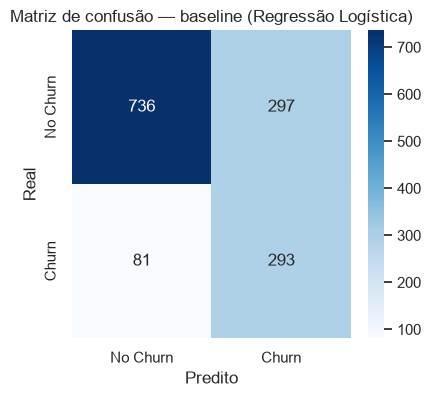

In [62]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(4.5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Churn", "Churn"], yticklabels=["No Churn", "Churn"])
plt.title("Matriz de confusão — baseline (Regressão Logística)")
plt.ylabel("Real")
plt.xlabel("Predito")
plt.show()


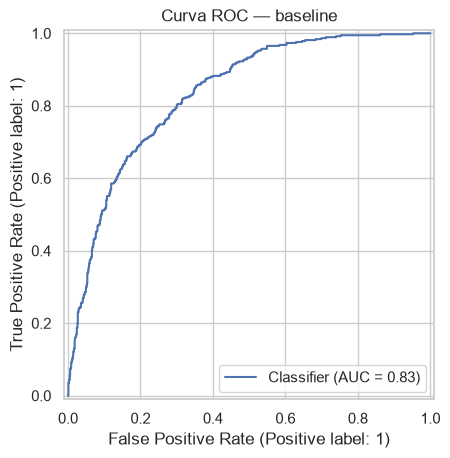

In [63]:
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC — baseline")
plt.show()


**Leitura dos resultados:** com SMOTE, o ROC-AUC permanece alto (~0.83–0.85) — esperado,
já que SMOTE não muda a capacidade de separação do modelo, apenas o ponto de operação. O que
muda é o equilíbrio entre precisão e recall: comparado ao baseline sem balanceamento, o
**recall da classe Churn aumenta bastante** (o modelo passa a capturar mais clientes que de
fato cancelariam), às custas de uma **queda na precisão** (mais falsos positivos). O efeito
líquido sobre o F1 é confirmado formalmente na seção 9 via validação cruzada, lado a lado com
as demais variações (sem balanceamento, `class_weight`, SMOTE + features, threshold).


## 9. Testando possibilidades — variações do baseline

Antes de avançar para modelos mais complexos (próxima etapa: Random Forest e MLP), testamos
variações simples e de baixo custo. Um único split de treino/teste é ruidoso para diferenças
pequenas de F1, então essa comparação usa **validação cruzada estratificada (5 folds) no
conjunto de treino** — a mesma lógica da seção 8, garantindo que o SMOTE (quando presente) seja
recalculado a cada fold, apenas na parte de treino do fold, sem tocar na parte de validação:

1. **Sem balanceamento**: baseline original, sem SMOTE e sem `class_weight` — referência para
   medir o ganho real do balanceamento.
2. **`class_weight="balanced"`**: penaliza mais os erros na classe minoritária, sem gerar
   dados sintéticos.
3. **SMOTE** (a escolha usada como baseline oficial na seção 7).
4. **SMOTE + features de engenharia** (seção 6): testa se as features derivadas ajudam quando
   combinadas ao balanceamento.

O ajuste de threshold, por depender de probabilidades preditas em dados não vistos no
treinamento, é avaliado separadamente no conjunto de teste, ao final desta seção.


In [64]:
def construir_pipeline(colunas_num, colunas_cat, usar_smote=False, **kwargs_modelo):
    """Monta um pipeline de pré-processamento + (opcionalmente) SMOTE + Regressão Logística.

    Se usar_smote=True, usa o Pipeline do imbalanced-learn, que reamostra somente a parte de
    treino de cada fold/split, nunca a parte de validação/teste — evitando vazamento de dados.
    """
    prep = ColumnTransformer([
        ("num", StandardScaler(), colunas_num),
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="if_binary"), colunas_cat),
    ])

    etapas = [("preprocessador", prep)]
    if usar_smote:
        etapas.append(("smote", SMOTE(random_state=RANDOM_STATE)))
    etapas.append(("classificador", LogisticRegression(
        max_iter=1000, random_state=RANDOM_STATE, **kwargs_modelo
    )))

    ClasseDoPipeline = ImbPipeline if usar_smote else Pipeline
    return ClasseDoPipeline(etapas)


def avaliar_cv(pipeline, X_tr, y_tr):
    """Roda validação cruzada estratificada e retorna a média das métricas."""
    scores = cross_validate(
        pipeline, X_tr, y_tr, cv=cv, scoring=["f1", "roc_auc", "precision", "recall"]
    )
    return {
        "f1": scores["test_f1"].mean(),
        "roc_auc": scores["test_roc_auc"].mean(),
        "precision": scores["test_precision"].mean(),
        "recall": scores["test_recall"].mean(),
    }


In [65]:
resultados_cv = {}

# 1) Sem balanceamento (referência)
pipe_sem_bal = construir_pipeline(colunas_numericas, colunas_categoricas)
resultados_cv["Sem balanceamento"] = avaliar_cv(pipe_sem_bal, X_train, y_train)

# 2) class_weight balanced
pipe_bal = construir_pipeline(colunas_numericas, colunas_categoricas, class_weight="balanced")
resultados_cv["class_weight balanced"] = avaliar_cv(pipe_bal, X_train, y_train)

# 3) SMOTE (baseline oficial, seção 7)
pipe_smote = construir_pipeline(colunas_numericas, colunas_categoricas, usar_smote=True)
resultados_cv["SMOTE (baseline)"] = avaliar_cv(pipe_smote, X_train, y_train)

# 4) SMOTE + feature engineering
X_train_fe = engenharia_features(X_train)
colunas_cat_fe = colunas_categoricas + ["tenure_group"]
colunas_num_fe = colunas_numericas + ["num_services"]
pipe_smote_fe = construir_pipeline(colunas_num_fe, colunas_cat_fe, usar_smote=True)
resultados_cv["SMOTE + features"] = avaliar_cv(pipe_smote_fe, X_train_fe, y_train)

tabela_comparativa = pd.DataFrame(resultados_cv).T.round(3)
tabela_comparativa


,f1,roc_auc,precision,recall
Sem balanceamento,0.595,0.846,0.654,0.546
class_weight balanced,0.633,0.846,0.522,0.803
SMOTE (baseline),0.630,0.845,0.523,0.792
SMOTE + features,0.630,0.846,0.523,0.793


In [66]:
# Ajuste de threshold: avaliado no conjunto de teste, sobre o modelo final (SMOTE) já
# treinado na seção 8 (`baseline`), reaproveitando y_proba calculado ali.
precisao, recall, thresholds = precision_recall_curve(y_test, y_proba)
f1_por_threshold = 2 * precisao * recall / (precisao + recall + 1e-9)
melhor_idx = np.argmax(f1_por_threshold)
melhor_threshold = thresholds[melhor_idx] if melhor_idx < len(thresholds) else 0.5
pred_thr = (y_proba >= melhor_threshold).astype(int)

tabela_comparativa.loc[f"SMOTE + threshold={melhor_threshold:.2f} (teste)"] = {
    "f1": f1_score(y_test, pred_thr),
    "roc_auc": roc_auc_score(y_test, y_proba),
    "precision": precision_score(y_test, pred_thr),
    "recall": recall_score(y_test, pred_thr),
}
tabela_comparativa.round(3)


,f1,roc_auc,precision,recall
Sem balanceamento,0.595,0.846,0.654,0.546
class_weight balanced,0.633,0.846,0.522,0.803
SMOTE (baseline),0.630,0.845,0.523,0.792
SMOTE + features,0.630,0.846,0.523,0.793
SMOTE + threshold=0.67 (teste),0.626,0.834,0.595,0.660


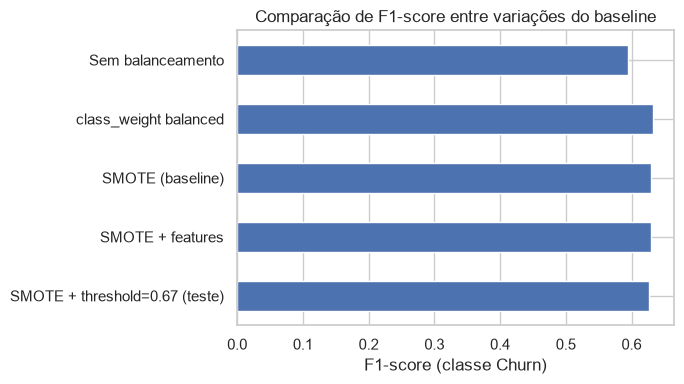

In [67]:
tabela_comparativa["f1"].plot(kind="barh", figsize=(7, 4), color="#4C72B0")
plt.title("Comparação de F1-score entre variações do baseline")
plt.xlabel("F1-score (classe Churn)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


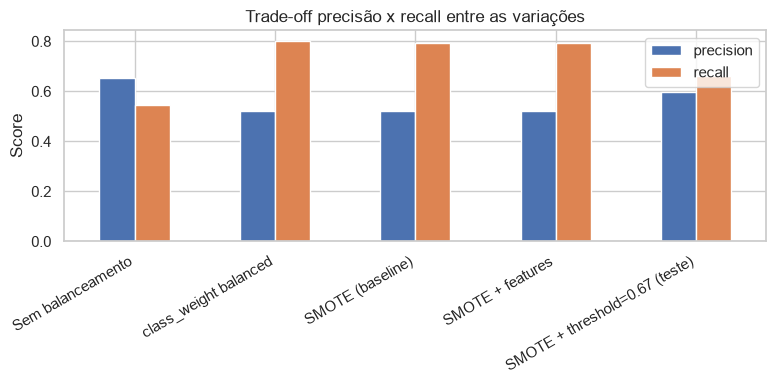

In [57]:
tabela_comparativa[["precision", "recall"]].plot(kind="bar", figsize=(8, 4))
plt.title("Trade-off precisão x recall entre as variações")
plt.ylabel("Score")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


**Conclusão dos testes** (as quatro primeiras linhas vêm de validação cruzada no treino,
mais confiáveis que um único split; a última linha usa o conjunto de teste, por depender de
probabilidades preditas fora do treino):

- **Balancear as classes realmente ajuda**: tanto `class_weight="balanced"` (F1 ≈ 0.633)
  quanto **SMOTE** (F1 ≈ 0.630) superam claramente o baseline sem balanceamento (F1 ≈ 0.595),
  com ganho concentrado no recall (de ~0.55 para ~0.79–0.80) e uma queda controlada de
  precisão. Para o problema de negócio (reter clientes em risco), esse trade-off costuma ser
  desejável — deixar de sinalizar um cliente que vai cancelar (falso negativo) tende a custar
  mais do que uma ação de retenção desnecessária (falso positivo).
- Nesta base, **SMOTE e `class_weight="balanced"` performam de forma muito próxima** — o
  desbalanceamento (27%) é moderado, não severo, então a criação de exemplos sintéticos do
  SMOTE não traz vantagem adicional relevante sobre simplesmente reponderar a função de perda.
  Como o pedido desta etapa foi explicitamente usar SMOTE, ele foi mantido como baseline
  oficial (seção 7) — mas vale registrar que `class_weight` é uma alternativa mais simples
  (sem gerar dados sintéticos) com resultado equivalente.
- **Features de engenharia** (`num_services`, `tenure_group`) combinadas ao SMOTE **não
  superam** o SMOTE isolado (F1 idêntico, 0.630) — são combinações/discretizações que o modelo
  linear já capta via as variáveis originais. **Decisão:** não incorporar por padrão;
  reavaliar em modelos não-lineares (Random Forest/MLP, próxima etapa).
- **Ajustar o threshold sobre o modelo com SMOTE**, avaliado no teste, muda o equilíbrio entre
  precisão (0.595) e recall (0.660) em relação ao corte padrão de 0.5 — uma opção de ajuste
  fino sem custo de re-treino, útil para calibrar o modelo conforme a capacidade operacional
  do time de retenção.


## 10. Análise de erros

Investigamos os casos em que o baseline original erra, buscando padrões que expliquem as
falhas e direcionem melhorias futuras.


In [68]:
analise_erros = X_test.copy()
analise_erros["churn_real"] = y_test.values
analise_erros["churn_predito"] = y_pred
analise_erros["proba_churn"] = y_proba

falsos_negativos = analise_erros[(analise_erros["churn_real"] == 1) & (analise_erros["churn_predito"] == 0)]
falsos_positivos = analise_erros[(analise_erros["churn_real"] == 0) & (analise_erros["churn_predito"] == 1)]

print(f"Falsos negativos: {len(falsos_negativos)} | Falsos positivos: {len(falsos_positivos)}")

falsos_negativos[["tenure", "Contract", "MonthlyCharges", "InternetService", "proba_churn"]].describe(include="all")


Falsos negativos: 81 | Falsos positivos: 297


,tenure,Contract,MonthlyCharges,InternetService,proba_churn
count,81.000000,81,81.000000,81,81.000000
unique,NaN,3,NaN,3,NaN
top,NaN,Month-to-month,NaN,DSL,NaN
freq,NaN,39,NaN,35,NaN
mean,29.950617,NaN,62.732099,NaN,0.311170
std,23.378356,NaN,31.521929,NaN,0.136621
min,1.000000,NaN,18.950000,NaN,0.008162
25%,5.000000,NaN,39.100000,NaN,0.216358
50%,31.000000,NaN,60.350000,NaN,0.324596
75%,49.000000,NaN,94.100000,NaN,0.418782


Os falsos negativos (clientes que cancelaram mas o modelo não sinalizou) tendem a
concentrar probabilidades próximas ao limiar de decisão — reforça a relevância do ajuste de
threshold visto na seção 9, e sugere que features adicionais (ex.: histórico de chamados de
suporte, NPS) poderiam ajudar a separar melhor esses casos-limite, caso estivessem disponíveis.


## 11. Conclusões e próximos passos

**Resumo do que foi entregue nesta etapa:**
- Base normalizada: `TotalCharges` convertido para numérico, registros inconsistentes
  removidos (com justificativa), identificador descartado, categorias padronizadas.
- EDA reestruturada com funções reutilizáveis, confirmando as hipóteses H1–H4.
- Baseline de Regressão Logística em pipeline scikit-learn/imbalanced-learn, **com SMOTE
  aplicado apenas no treino (sem vazamento de dados)**, priorizando recall na classe Churn.
- Cinco variações comparadas via validação cruzada (sem balanceamento, `class_weight`, SMOTE,
  SMOTE + features, threshold): o balanceamento (SMOTE ou `class_weight`) elevou o F1 de
  ~0.595 para ~0.63, e o ajuste de threshold no teste permite calibrar ainda mais o trade-off
  precisão/recall sem custo de re-treino.

**Próximos passos sugeridos (Etapa 2 do Tech Challenge):**
1. Treinar Random Forest e MLPClassifier, comparando com este baseline (com e sem SMOTE)
   usando o mesmo split e as mesmas métricas (F1, ROC-AUC) — verificar se capturam melhor as
   interações que a Regressão Logística não captura linearmente.
2. Reavaliar as features de engenharia (`num_services`, `tenure_group`) especificamente em
   modelos baseados em árvore, que lidam melhor com não-linearidades.
3. Testar variações da técnica de reamostragem (ex.: SMOTE-NC para lidar nativamente com
   variáveis categóricas, ou combinações de over/undersampling como SMOTETomek).
4. Formalizar a escolha de threshold como parte do pipeline de decisão (não apenas da
   avaliação), documentando o trade-off precisão/recall escolhido para o negócio.
5. Registrar os experimentos (mesmo que em uma tabela simples) para comparação entre etapas.
6. Investigar necessidade de dados adicionais (ex.: histórico de atendimento) para reduzir os
   falsos negativos identificados na análise de erros.
